# PERCOBAAN 2
grayscale, resize, gaussian blur, sharpening dan deteksi tepi (sobel)

In [5]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [6]:
data = []
labels = []
file_name = []

dataset_path = "." 

target_folders = ["Brokoli", "Kembang Kol"]

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    # Validasi: Pastikan itu adalah folder DAN termasuk dalam target_folders kita
    if not os.path.isdir(full_path) or sub_folder not in target_folders:
        continue  

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

# Opsional: Cetak jumlah data untuk memastikan loading berhasil
print(f"Total data gambar berhasil dimuat: {len(data)}")
print(f"Distribusi label: {np.unique(labels, return_counts=True)}")

Total data gambar berhasil dimuat: 200
Distribusi label: (array(['Brokoli', 'Kembang Kol'], dtype='<U11'), array([100, 100]))


## Data Preparation

### Data Preprocessing

In [7]:
def grayscale(image):
    if len(image.shape) == 2:
        return image
    elif len(image.shape) == 3:
        r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
        gray_image = 0.299 * r + 0.587 * g + 0.114 * b
        return gray_image.astype(np.uint8)
    else:
        raise ValueError("Input image must be either grayscale or RGB")

def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros(
        (new_height, new_width),
        dtype=np.uint8
    )

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size
    padded = np.pad(img, pad_size, mode='constant')

    canvas = np.zeros_like(img).astype(np.float32)
    h, w = img.shape

    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    
    return canvas

# kernel smoothing
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])


def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    
    if np.max(canvas) > 0:
        canvas = canvas * 255.0 / np.max(canvas)
    
    return np.clip(canvas, 0, 255).astype(np.uint8)

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

### Preprocessing

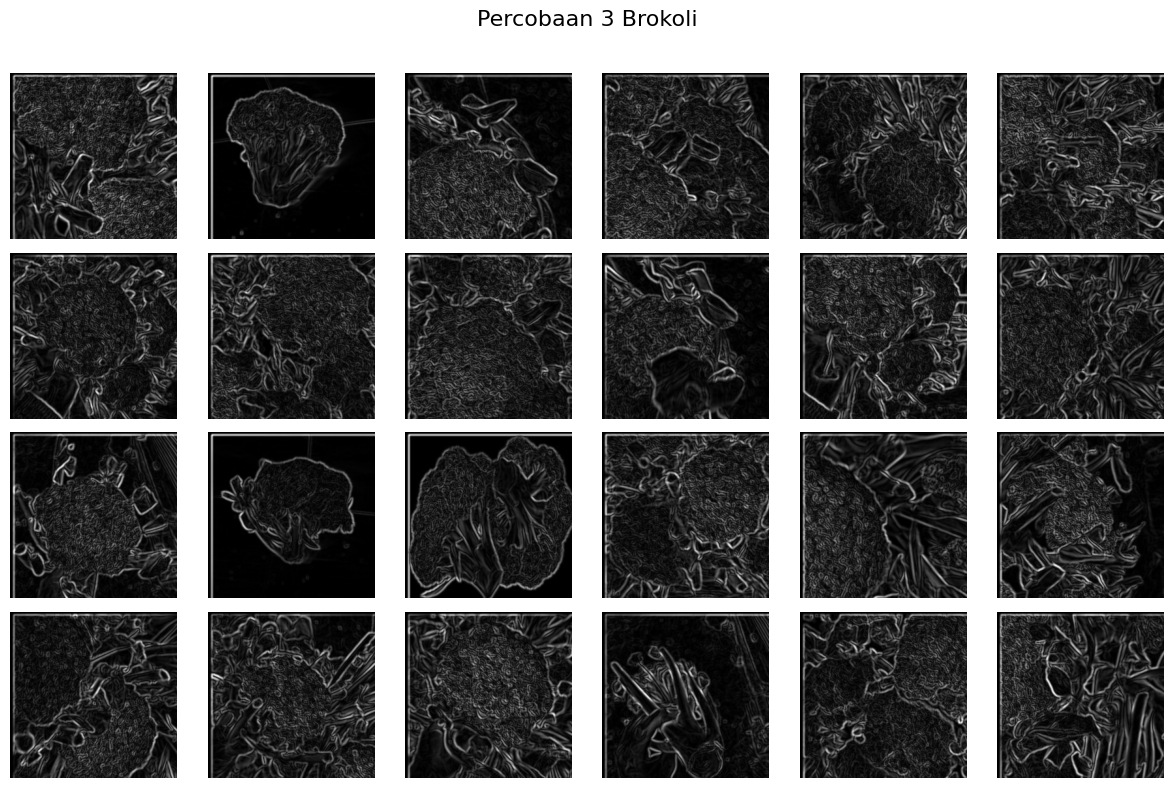

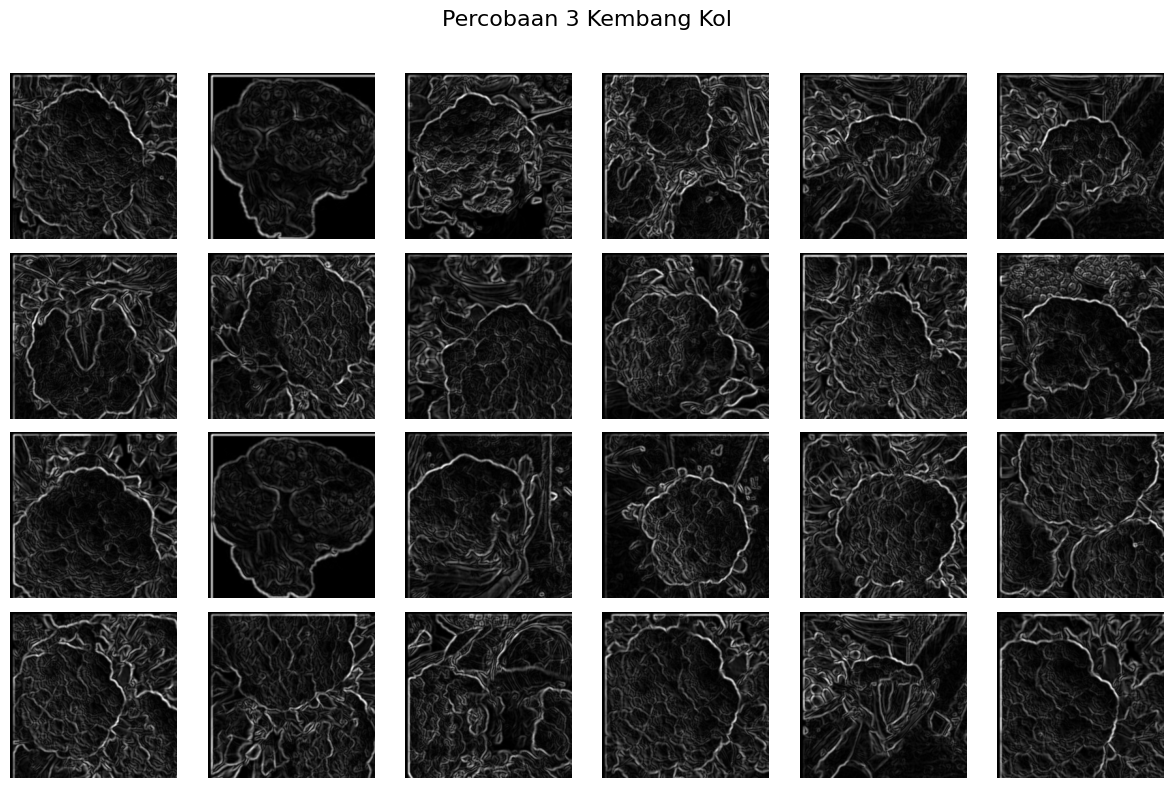

In [8]:
def percobaan3(img):
    img_gray        = grayscale(img)
    img_resize      = resize(img_gray, 256, 256)
    img_smoothing   = convolution(img_resize, kernelSmoothing)
    img_sharpening  = convolution(img_smoothing, kernelSharpening)
    img_edge        = edge(img_sharpening, sobelX, sobelY)
    return img_edge

dataPreprocessed = [percobaan3(img) for img in data]  

unique_labels = sorted(set(labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(labels) if l == label]
    
    # Buat grid 7x12 (cukup untuk 84 gambar, 7*12 = 84)
    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Percobaan 3 {label}', fontsize=16)
    
    for k in range(24):
        row = k // 6
        col = k % 6
        ax = axs[row][col]
        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # beri ruang untuk judul
    plt.show()

### Ekstraksi Fitur

In [9]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [10]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [13]:
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0
        
        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan3')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,406.431664,0.821884,0.026063,0.114724,14.269072,0.000679,8.668517,percobaan3
1,199.548514,0.896637,0.250689,0.544140,5.527374,0.062845,5.385157,percobaan3
2,259.939905,0.869278,0.044794,0.222439,10.121278,0.002006,7.900598,percobaan3
3,275.711474,0.841715,0.028061,0.137479,11.311596,0.000787,8.316787,percobaan3
4,312.722488,0.837765,0.028519,0.131522,12.013511,0.000813,8.333733,percobaan3
...,...,...,...,...,...,...,...,...
195,195.491345,0.904422,0.029248,0.161344,9.231970,0.000855,8.218804,percobaan3
196,260.413251,0.867490,0.035474,0.175989,9.982920,0.001258,7.970157,percobaan3
197,287.910263,0.857843,0.028989,0.134948,11.541697,0.000840,8.327282,percobaan3
198,239.582215,0.873130,0.035047,0.171089,9.499127,0.001228,7.936225,percobaan3


In [14]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    citra_fix = dataPreprocessed[i].astype(np.uint8)

    D0 = glcm(citra_fix, 0)
    D45 = glcm(citra_fix, 45)
    D90 = glcm(citra_fix, 90)
    D135 = glcm(citra_fix, 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Ekstraksi ke CSV

In [15]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

In [16]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0001.jpg,Brokoli,406.431664,841.176071,446.736612,613.662422,0.114724,0.087244,0.120961,0.092438,...,0.000694,0.000495,0.026063,0.021912,0.026346,0.022239,0.821884,0.631329,0.804511,0.731040
1,0002.jpg,Brokoli,199.548514,367.268958,170.714369,341.647136,0.544140,0.470293,0.537691,0.488977,...,0.058561,0.051601,0.250689,0.224733,0.241994,0.227159,0.896637,0.810202,0.911573,0.823443
2,0003.jpg,Brokoli,259.939905,395.186128,325.976884,603.840400,0.222439,0.186413,0.209663,0.163579,...,0.001922,0.001384,0.044794,0.039301,0.043840,0.037198,0.869278,0.801322,0.836037,0.696424
3,0004.jpg,Brokoli,275.711474,501.317586,343.668719,556.448058,0.137479,0.107325,0.126781,0.101822,...,0.000750,0.000551,0.028061,0.023829,0.027381,0.023480,0.841715,0.712053,0.802700,0.680391
4,0005.jpg,Brokoli,312.722488,468.564937,267.308241,545.823637,0.131522,0.108118,0.140678,0.106429,...,0.000855,0.000609,0.028519,0.024711,0.029241,0.024681,0.837765,0.756919,0.861443,0.716842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0096.jpg,Kembang Kol,195.491345,457.660361,307.073376,470.727489,0.161344,0.123160,0.146039,0.112896,...,0.000809,0.000579,0.029248,0.024498,0.028450,0.024056,0.904422,0.775997,0.849817,0.769603
196,0097.jpg,Kembang Kol,260.413251,379.166228,202.390533,453.784529,0.175989,0.149258,0.194044,0.138809,...,0.001351,0.000920,0.035474,0.031265,0.036757,0.030330,0.867490,0.807137,0.896944,0.769183
197,0098.jpg,Kembang Kol,287.910263,460.153772,275.308349,542.353787,0.134948,0.119977,0.146610,0.106495,...,0.000888,0.000620,0.028989,0.025666,0.029804,0.024898,0.857843,0.772679,0.864042,0.732074
198,0099.jpg,Kembang Kol,239.582215,413.492780,243.327191,466.073387,0.171089,0.142782,0.166696,0.127980,...,0.001219,0.000884,0.035047,0.030386,0.034917,0.029732,0.873130,0.781190,0.871169,0.753367


## Feature Selection

### ANOVA (Analysis of Variance)

Berdasarkan pengujian seleksi fitur berbasis nilai mentah piksel menggunakan metode ANOVA (Analysis of Variance), sistem telah berhasil mengevaluasi tingkat signifikansi dari seluruh 65.536 fitur piksel yang berasal dari reduksi dimensi citra berukuran 256 x 256 piksel. Hasil perhitungan menunjukkan bahwa Piksel_33419 memiliki tingkat pengaruh tertinggi dalam membedakan kedua kelas objek dengan capaian nilai F-Score sebesar 69,58, yang kemudian diikuti secara ketat oleh Piksel_33418 dengan skor 69,21 dan Piksel_33420 dengan skor 67,86. Tingginya nilai F-Score pada fitur-fitur tersebut mengindikasikan adanya rasio variansi antar-kelas yang besar dan konsisten, sehingga titik-titik tersebut memuat informasi visual yang sangat kontras untuk memisahkan objek brokoli dan kembang kol. Secara spasial atau geografis citra, jika indeks fitur linear tersebut dikembalikan ke dalam koordinat dua dimensi (X, Y), urutan piksel terbaik ini berada tepat di Baris ke-130 dan Kolom ke-131. Posisi koordinat ini membuktikan secara logis dan statistik bahwa area yang terletak tepat di tengah-tengah gambar yang merupakan pusat sebaran gumpalan bunga serta kepadatan tekstur sayur menyimpan karakteristik pembeda paling valid dan krusial bagi algoritma klasifikasi, sementara area latar belakang (background) otomatis dieliminasi oleh fungsi ANOVA karena bersifat konstan dan tidak informatif.

In [17]:
X_images = np.array(dataPreprocessed)

# FLATTEN: Ubah gambar 2D (256x256) menjadi 1D (65536 fitur)
jumlah_sampel = X_images.shape[0]
X_asli = X_images.reshape(jumlah_sampel, -1) 

y_asli = np.array(labels)

nama_fitur = [f"Piksel_{i}" for i in range(X_asli.shape[1])]
X_train, X_test, y_train, y_test = train_test_split(X_asli, y_asli, test_size=0.2, random_state=42)

print(f"Data berhasil dimuat!")
print(f"Ukuran data training: {X_train.shape} (Artinya: {X_train.shape[0]} gambar, {X_train.shape[1]} nilai piksel)")

# ANOVA: Menghitung skor pengaruh setiap piksel dalam membedakan Brokoli vs Kembang Kol
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

skor_anova = np.nan_to_num(selector.scores_, nan=0.0, posinf=0.0, neginf=0.0)

df_pengaruh = pd.DataFrame({
    'Nama Piksel/Fitur': nama_fitur,
    'F-Score (Pengaruh)': skor_anova # Gunakan skor yang sudah bersih
}).sort_values(by='F-Score (Pengaruh)', ascending=False)

print("\n--- URUTAN PIKSEL HASIL PREPROCESSING PALING BERPENGARUH ---")
print(df_pengaruh.head(10).to_string(index=False)) 
print("\n" + "="*50 + "\n")

Data berhasil dimuat!
Ukuran data training: (160, 65536) (Artinya: 160 gambar, 65536 nilai piksel)

--- URUTAN PIKSEL HASIL PREPROCESSING PALING BERPENGARUH ---
Nama Piksel/Fitur  F-Score (Pengaruh)
     Piksel_32389           27.115942
     Piksel_31124           25.986045
     Piksel_31380           24.220681
     Piksel_23181           24.215854
     Piksel_25759           23.945062
     Piksel_36519           23.695827
     Piksel_27001           23.658230
     Piksel_23436           22.587504
     Piksel_27000           22.508147
     Piksel_23180           22.296388




c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [    0     1     2 ... 65280 65281 65282] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


### Correlation

Berdasarkan hasil pengujian klasifikasi menggunakan algoritma Random Forest, seleksi fitur ini memberikan dua dampak performa yang berbeda tergantung pada optimalnya jumlah fitur yang dipertahankan. Pada kondisi pertama (percobaan1), penyaringan yang terlalu ketat hingga menyisakan 3 fitur utama (Contrast0, Homogeneity0, ASM0) justru membuang informasi tekstur krusial pada sudut lainnya, sehingga menyebabkan penurunan akurasi model dari 92,50% menjadi 82,50%. Sebaliknya, pada kondisi kedua (percobaan2), penyaringan yang menyisakan 5 fitur inti (Contrast0, Homogeneity0, Dissimilarity0, ASM0, Correlation0) berhasil membuang komponen noise atau gangguan data tanpa kehilangan informasi penting. Hal ini dibuktikan dengan adanya lonjakan akurasi model yang meningkat dari 90,00% menjadi 95,00%. Dengan demikian, dapat disimpulkan bahwa reduksi dimensi fitur GLCM yang tepat tidak hanya menyederhanakan arsitektur komputasi model, tetapi juga mampu mengoptimalkan kemampuan algoritma dalam mengenali karakteristik tekstur pembeda antara brokoli dan kembang kol.

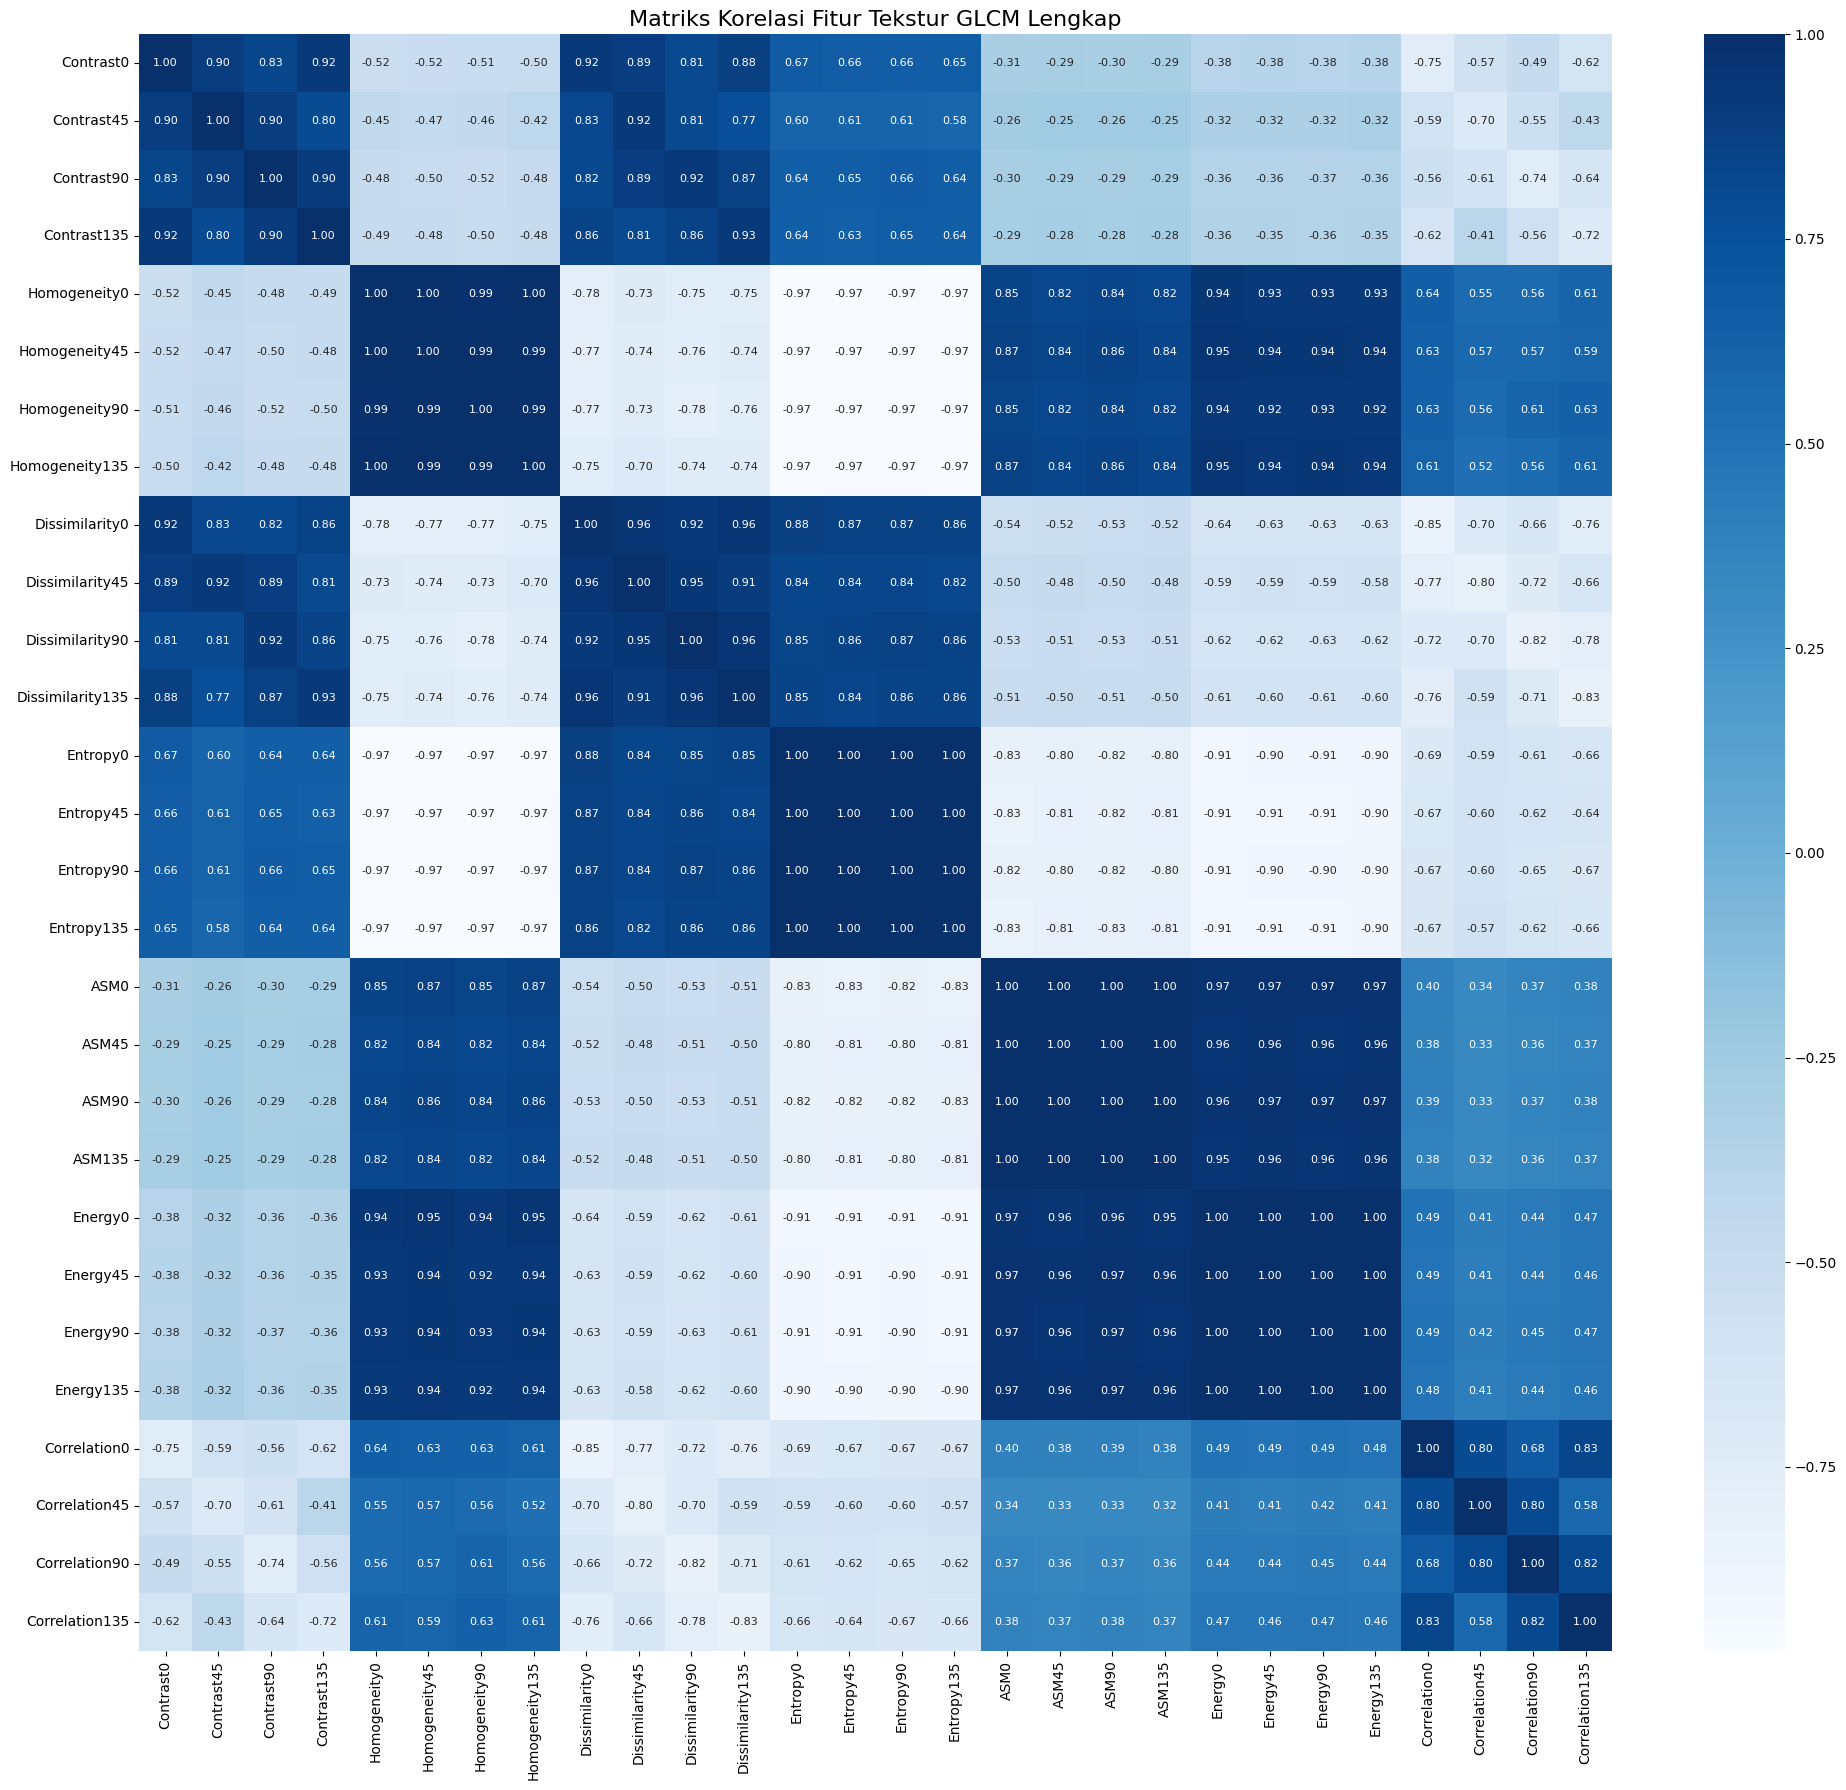

--- HASIL SELEKSI FITUR ---
Jumlah fitur awal : 28 fitur
Jumlah fitur setelah disaring (Korelasi < 0.85) : 6 fitur
Fitur yang terpilih: ['Contrast0', 'Homogeneity0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']

Akurasi SEBELUM Seleksi Korelasi (28 fitur): 87.50%
Akurasi SETELAH Seleksi Korelasi (6 fitur) : 85.00%


In [18]:
correlation = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation, annot=True, cmap='Blues', fmt=".2f", cbar=True, annot_kws={"size": 8})
plt.title("Matriks Korelasi Fitur Tekstur GLCM Lengkap", fontsize=16)
plt.tight_layout()
plt.show()

threshold = 0.85 
columns_mask = np.full((correlation.shape[0],), True, dtype=bool)

for i in range(correlation.shape[0]):
    for j in range(i+1, correlation.shape[0]):
        if abs(correlation.iloc[i, j]) >= threshold:
            if columns_mask[j]:
                columns_mask[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns_mask]

x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"--- HASIL SELEKSI FITUR ---")
print(f"Jumlah fitur awal : {correlation.shape[0]} fitur")
print(f"Jumlah fitur setelah disaring (Korelasi < {threshold}) : {x_new.shape[1]} fitur")
print(f"Fitur yang terpilih: {list(select)}\n")

# Split data menggunakan fitur awal vs fitur baru
X_train_old, X_test_old, y_train, y_test = train_test_split(
    hasilEkstrak.drop(columns=['Label', 'Filename']), y, test_size=0.2, random_state=42
)
X_train_new, X_test_new, _, _ = train_test_split(x_new, y, test_size=0.2, random_state=42)

# Model dengan fitur awal
model_old = RandomForestClassifier(random_state=42)
model_old.fit(X_train_old, y_train)
acc_old = accuracy_score(y_test, model_old.predict(X_test_old))

# Model dengan fitur hasil seleksi
model_new = RandomForestClassifier(random_state=42)
model_new.fit(X_train_new, y_train)
acc_new = accuracy_score(y_test, model_new.predict(X_test_new))

print("="*60)
print(f"Akurasi SEBELUM Seleksi Korelasi ({correlation.shape[0]} fitur): {acc_old * 100:.2f}%")
print(f"Akurasi SETELAH Seleksi Korelasi ({x_new.shape[1]} fitur) : {acc_new * 100:.2f}%")
print("="*60)

### Splitting Data

In [19]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 6)
(40, 6)
(160,)
(40,)


### Feature Normalization

In [20]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

### Define Model

In [21]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [22]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.99      1.00      0.99        79
 Kembang Kol       1.00      0.99      0.99        81

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160

[[79  0]
 [ 1 80]]
Accuracy: 0.99375

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.82      0.86      0.84        21
 Kembang Kol       0.83      0.79      0.81        19

    accuracy                           0.82        40
   macro avg       0.83      0.82      0.82        40
weighted avg       0.83      0.82      0.82        40

[[18  3]
 [ 4 15]]
Accuracy: 0.825


### Train SVM Classifier

In [23]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.95      0.96      0.96        79
 Kembang Kol       0.96      0.95      0.96        81

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160

[[76  3]
 [ 4 77]]
Accuracy: 0.95625

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.90      0.86      0.88        21
 Kembang Kol       0.85      0.89      0.87        19

    accuracy                           0.88        40
   macro avg       0.88      0.88      0.87        40
weighted avg       0.88      0.88      0.88        40

[[18  3]
 [ 2 17]]
Accuracy: 0.875


### Train KNN Classifier

In [24]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.99      0.84      0.90        79
 Kembang Kol       0.86      0.99      0.92        81

    accuracy                           0.91       160
   macro avg       0.92      0.91      0.91       160
weighted avg       0.92      0.91      0.91       160

[[66 13]
 [ 1 80]]
Accuracy: 0.9125

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.94      0.81      0.87        21
 Kembang Kol       0.82      0.95      0.88        19

    accuracy                           0.88        40
   macro avg       0.88      0.88      0.87        40
weighted avg       0.88      0.88      0.87        40

[[17  4]
 [ 1 18]]
Accuracy: 0.875


### Evaluasi dengan Confussion Matrix

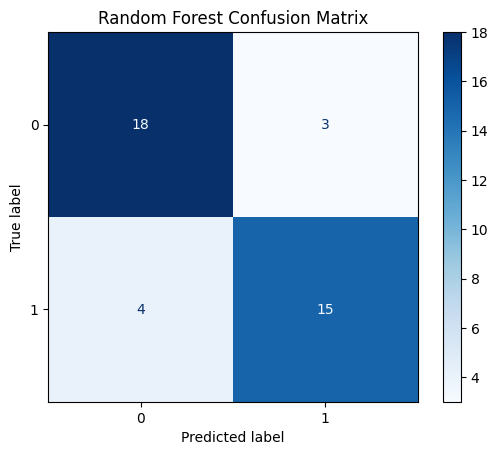

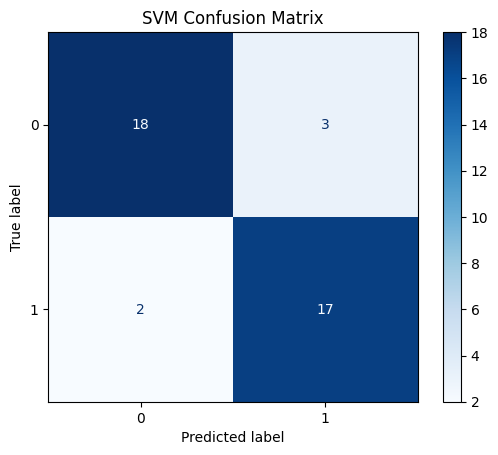

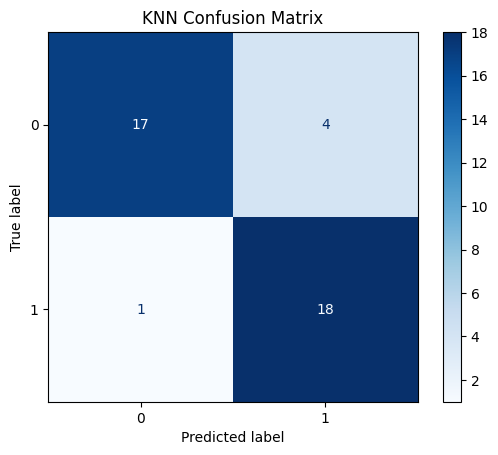

In [25]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")